# making more wont stop (Edition 3)

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8] 

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [34]:
block_size = 3

def build_database(words):
    X, Y = [], []

    for w in words:
        context = [0] *block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_database(words[:n1])
Xdev, Yval = build_database(words[n1:n2])
Xte, Yte = build_database(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [35]:
n_embd = 10
n_hidden = 200

g = torch.Generator()
C = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn((vocab_size),                    generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

11897


In [36]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item(): .4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000:  3.3097
  10000/ 200000:  2.4064
  20000/ 200000:  2.2687
  30000/ 200000:  2.1848
  40000/ 200000:  2.2161
  50000/ 200000:  2.6181
  60000/ 200000:  2.0265
  70000/ 200000:  2.2682
  80000/ 200000:  2.1230
  90000/ 200000:  2.5720
 100000/ 200000:  2.0857
 110000/ 200000:  2.3036
 120000/ 200000:  2.1179
 130000/ 200000:  2.1683
 140000/ 200000:  2.0237
 150000/ 200000:  2.2401
 160000/ 200000:  1.8785
 170000/ 200000:  1.9666
 180000/ 200000:  2.1533
 190000/ 200000:  1.8879


(array([1218.,  309.,  152.,  136.,  110.,  121.,   77.,   76.,   65.,
          77.,   60.,   49.,   53.,   34.,   49.,   50.,   67.,   42.,
          56.,   51.,   59.,   57.,   68.,   62.,   62.,   51.,   60.,
          69.,   52.,   49.,   59.,   71.,   53.,   64.,   63.,   74.,
          59.,   61.,   69.,   58.,   54.,   56.,   68.,   85.,   99.,
         128.,  147.,  183.,  268., 1240.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

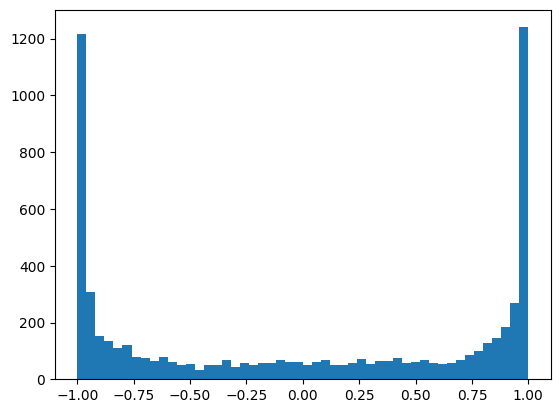

In [37]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   0.,   1.,   5.,   6.,   5.,   6.,  13.,  23.,  26.,  40.,
         62.,  66.,  87.,  97., 144., 186., 229., 243., 324., 315., 371.,
        353., 515., 527., 458., 331., 364., 286., 266., 228., 171., 160.,
        130.,  96.,  61.,  50.,  46.,  33.,  22.,  14.,  13.,   7.,   3.,
          3.,   5.,   3.,   3.,   1.,   1.]),
 array([-9.0470953 , -8.67132561, -8.29555592, -7.91978622, -7.54401653,
        -7.16824684, -6.79247715, -6.41670746, -6.04093777, -5.66516808,
        -5.28939838, -4.91362869, -4.537859  , -4.16208931, -3.78631962,
        -3.41054993, -3.03478024, -2.65901054, -2.28324085, -1.90747116,
        -1.53170147, -1.15593178, -0.78016209, -0.4043924 , -0.0286227 ,
         0.34714699,  0.72291668,  1.09868637,  1.47445606,  1.85022575,
         2.22599545,  2.60176514,  2.97753483,  3.35330452,  3.72907421,
         4.1048439 ,  4.48061359,  4.85638329,  5.23215298,  5.60792267,
         5.98369236,  6.35946205,  6.73523174,  7.11100143,  7.48677113,
 

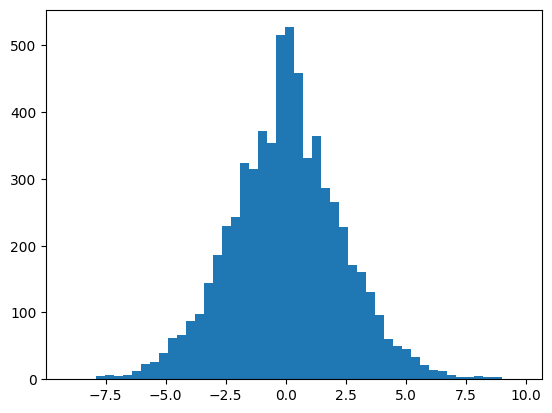

In [38]:
plt.hist(hpreact.view(-1).tolist(), 50)

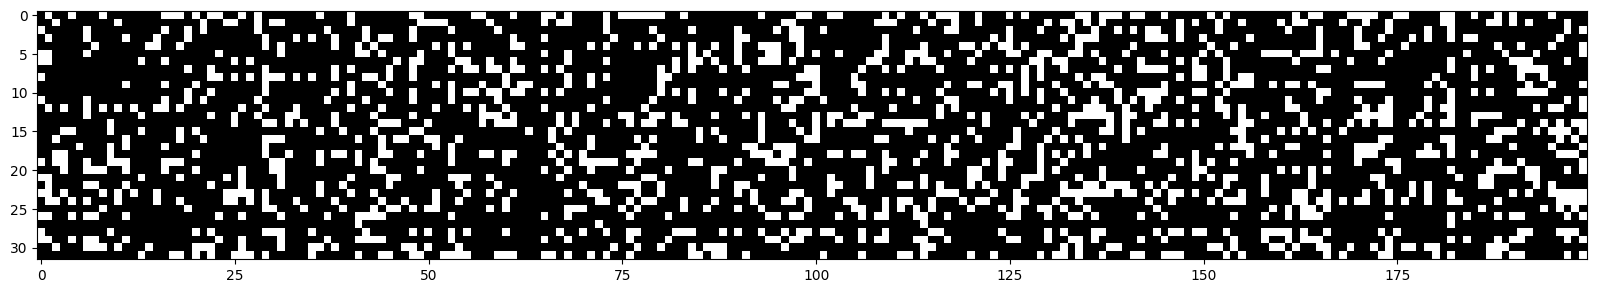

In [39]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

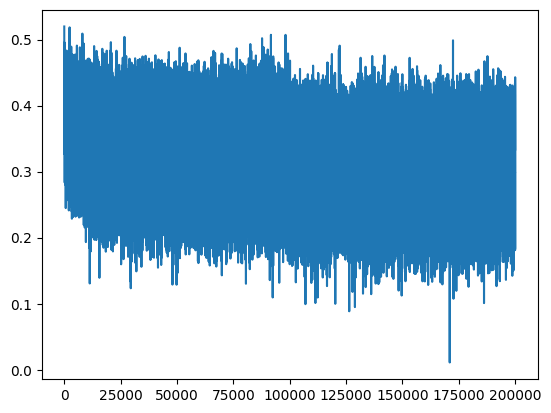

In [40]:
plt.plot(lossi)

In [41]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Yval),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.0382843017578125
val 2.1054232120513916
test 2.108189105987549


In [42]:
g = torch.Generator()

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

kodolo.
wheevie.
adrawlan.
zayd.
helie.
niveon.
jeders.
maversyn.
kalopiero.
azely.
garlu.
zicusnayler.
bronwikvyena.
wlox.
azadel.
blay.
ami.
davi.
halaya.
kianeashaaknaya.
